<a href="https://colab.research.google.com/github/Rvpatil-tech/Machine-learning-projects-/blob/main/Breast_Cancer_classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split


DATA COLLECTION AND PROCESSING

In [ ]:
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [ ]:
data=pd.DataFrame(breast_cancer_dataset.data,columns=breast_cancer_dataset.feature_names)

In [ ]:
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
data['target']=breast_cancer_dataset.target

In [ ]:
data.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [ ]:
data.shape

(569, 31)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
data.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [ ]:
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
data['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

where 0=Malignant and 1=begingn




In [ ]:
data.groupby('target').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


SPLITTING DATA

In [ ]:
x=data.drop(columns='target',axis=1) #to drop a column axis=1 and for row axis=0
y=data['target']

In [ ]:
print(x)
print(y)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [ ]:
a_train,a_test,b_train,b_test=train_test_split(x,y,test_size=0.2,random_state=2)
print(a_train.shape,a_test.shape,x.shape)

(455, 30) (114, 30) (569, 30)


STANDARDIZE THE DATA

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
a_train_std=scaler.fit_transform(a_train)
a_test_std=scaler.transform(a_test)

In [ ]:
print(a_train_std)

[[-0.01330339  1.7757658  -0.01491962 ... -0.13236958 -1.08014517
  -0.03527943]
 [-0.8448276  -0.6284278  -0.87702746 ... -1.11552632 -0.85773964
  -0.72098905]
 [ 1.44755936  0.71180168  1.47428816 ...  0.87583964  0.4967602
   0.46321706]
 ...
 [-0.46608541 -1.49375484 -0.53234924 ... -1.32388956 -1.02997851
  -0.75145272]
 [-0.50025764 -1.62161319 -0.527814   ... -0.0987626   0.35796577
  -0.43906159]
 [ 0.96060511  1.21181916  1.00427242 ...  0.8956983  -1.23064515
   0.50697397]]


BUILDING ANN

In [ ]:
import tensorflow as tf
tf.random.set_seed(3) #used to avoid changes in accuracy as everytime the code runs some parameters will be initialized
from tensorflow import keras
#tensorflow is a dl library developed by google

In [ ]:
# setting up layers of ANN
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),   #input layer
    keras.layers.Dense(20,activation='relu'),  #hidden layer relu= rectified linear units
    keras.layers.Dense(2,activation='sigmoid') ]) #output layer sigmoid is similar to logistic regression

In [ ]:
#compiling the ANN
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#training
history=model.fit(a_train_std,b_train,validation_split=0.1,epochs=10)
# epoch - how many times the model has to go through the data

Epoch 1/10
13/13 [==============================] - 1s 17ms/step - loss: 0.3763 - accuracy: 0.8704 - val_loss: 0.2563 - val_accuracy: 0.9130
Epoch 2/10
13/13 [==============================] - 0s 4ms/step - loss: 0.2485 - accuracy: 0.9144 - val_loss: 0.1868 - val_accuracy: 0.9348
Epoch 3/10
13/13 [==============================] - 0s 4ms/step - loss: 0.1913 - accuracy: 0.9218 - val_loss: 0.1588 - val_accuracy: 0.9565
Epoch 4/10
13/13 [==============================] - 0s 6ms/step - loss: 0.1597 - accuracy: 0.9364 - val_loss: 0.1421 - val_accuracy: 0.9565
Epoch 5/10
13/13 [==============================] - 0s 6ms/step - loss: 0.1379 - accuracy: 0.9609 - val_loss: 0.1300 - val_accuracy: 0.9565
Epoch 6/10
13/13 [==============================] - 0s 6ms/step - loss: 0.1216 - accuracy: 0.9609 - val_loss: 0.1212 - val_accuracy: 0.9783
Epoch 7/10
13/13 [==============================] - 0s 5ms/step - loss: 0.1094 - accuracy: 0.9707 - val_loss: 0.1123 - val_accuracy: 0.9783
Epoch 8/10
13/13 [=

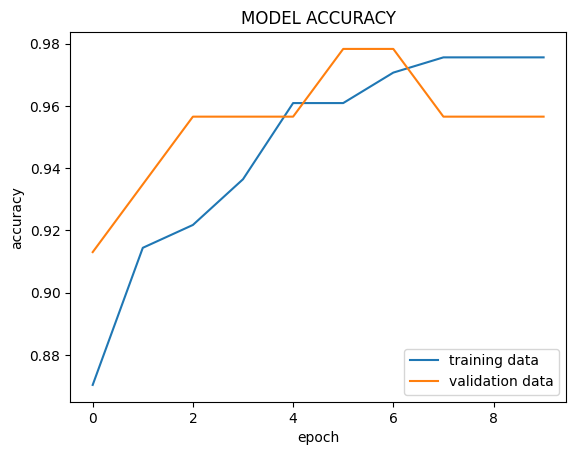

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('MODEL ACCURACY')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='lower right')

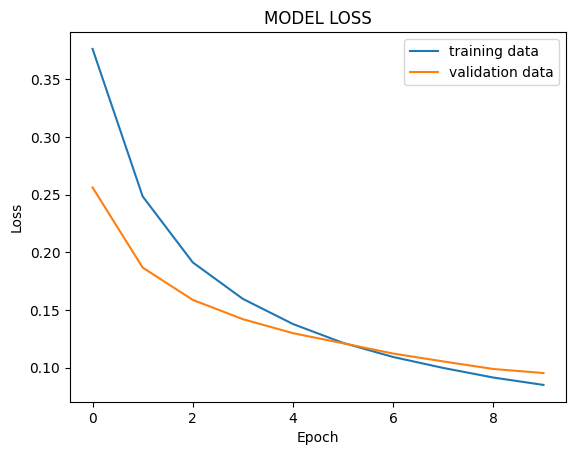

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MODEL LOSS')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['training data','validation data'],loc='upper right')

TESTING MODEL ACCURACY

In [ ]:
loss,accuracy=model.evaluate(a_test_std,b_test)
print(accuracy)

4/4 [==============================] - 0s 4ms/step - loss: 0.0997 - accuracy: 0.9649
0.9649122953414917


In [ ]:
print(a_test_std.shape)
print(a_test_std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


In [ ]:
b_pred=model.predict(a_test_std)
print(b_pred.shape)
print(b_pred[0])

4/4 [==============================] - 0s 4ms/step
(114, 2)
[0.14932309 0.30094624]


In [ ]:
print(b_pred)

[[1.49323091e-01 3.00946236e-01]
 [4.63972747e-01 5.10704458e-01]
 [2.07476132e-02 9.68150496e-01]
 [9.99896526e-01 7.75898079e-05]
 [2.98716009e-01 5.70096195e-01]
 [9.87626970e-01 8.12845677e-03]
 [2.75698721e-01 7.35503197e-01]
 [2.89892051e-02 9.19350803e-01]
 [6.82764277e-02 8.25251043e-01]
 [5.91516048e-02 8.25102031e-01]
 [6.11392558e-01 4.42915857e-01]
 [1.36802360e-01 8.37723792e-01]
 [2.83229768e-01 3.50804359e-01]
 [2.39171490e-01 6.89498007e-01]
 [4.06785309e-02 9.00072038e-01]
 [9.44895327e-01 2.20482517e-02]
 [5.56704067e-02 8.90593886e-01]
 [5.26154377e-02 8.72083306e-01]
 [3.83797437e-02 8.80077779e-01]
 [9.67959404e-01 2.84512341e-02]
 [1.23033896e-01 9.76011395e-01]
 [4.99939211e-02 8.89133155e-01]
 [8.26020017e-02 8.79354060e-01]
 [2.17111986e-02 8.65672469e-01]
 [8.89714882e-02 6.29050910e-01]
 [8.93961549e-01 4.90589105e-02]
 [1.47602558e-01 8.44459891e-01]
 [2.21295133e-01 6.07928097e-01]
 [6.34690225e-01 1.63481399e-01]
 [9.25567031e-01 4.31432165e-02]
 [9.831871

In [ ]:
my_list=[10,20,30]
index=np.argmax(my_list)
print(index)
print(my_list)

2
[10, 20, 30]


In [ ]:
b_pred_label=b_pred.argmax(axis=1)
print(b_pred_label)

[1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1
 1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 0
 1 0 1 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 0
 0 0 0]


PREDICTION SYSTEM

In [ ]:
input_data=(16.13,20.68,108.1,798.8,0.117,0.2022,0.1722,0.1028,0.2164,0.07356,0.5692,1.073,3.854,54.18,0.007026,0.02501,0.03188,0.01297,0.01689,0.004142,20.96,31.48,136.8,1315,0.1789,0.4233,0.4784,0.2073,0.3706,0.1142) # remove the first element from the tuple as it is not a feature

input_data_n=np.asarray(input_data)
input_data_reshaped=input_data_n.reshape(1,-1)

input_std= scaler.transform(input_data_reshaped)
prediction=model.predict(input_std)
print(prediction)

std_data=scaler.transform(input_data_reshaped)
prediction=model.predict(std_data)
print(prediction)

prediction_label= [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0]==0):
  print('The tumor is Malignant')
else:
  print('The tumor is Benign')

1/1 [==============================] - 0s 20ms/step
[[1. 1.]]
1/1 [==============================] - 0s 19ms/step
[[1. 1.]]
[0]
The tumor is Malignant
